In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np


In [2]:
data_path = '../data/'
df = pd.read_csv(data_path + 'Loan_data.csv')
dico = pd.read_excel(data_path + 'Dictionnaire_données.xlsx', sheet_name='Sheet1')
dico.drop(columns=['Unnamed: 0'], inplace=True)

In [3]:
count_na = df.isna().sum()
print(count_na)
df.dropna(inplace=True)

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [4]:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=42)

# Découpage de la partie restante en validation et test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)


In [5]:
target='RiskScore'
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_val = df_val.drop(columns=[target])
y_val = df_val[target]
X_test = df_test.drop(columns=[target])
y_test = df_test[target]

In [11]:
# col types
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved']
Categorical columns: ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


In [13]:
# catboost
from catboost import CatBoostRegressor, Pool

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

In [14]:
model_baseline = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

In [17]:
model_baseline.fit(train_pool, eval_set=val_pool)
y_pred = model_baseline.predict(test_pool)
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, y_pred)
print(f'RMSE on test set: {rmse}')
print(f'MAE on test set: {mean_absolute_error(y_test, y_pred)}')


0:	learn: 7.4139093	test: 7.5249256	best: 7.5249256 (0)	total: 8.03ms	remaining: 8.03s
100:	learn: 0.7490046	test: 0.7945510	best: 0.7945510 (100)	total: 521ms	remaining: 4.64s
200:	learn: 0.4075004	test: 0.4547290	best: 0.4547290 (200)	total: 971ms	remaining: 3.86s
300:	learn: 0.2930884	test: 0.3467592	best: 0.3467592 (300)	total: 1.48s	remaining: 3.44s
400:	learn: 0.2350220	test: 0.2947158	best: 0.2947158 (400)	total: 1.93s	remaining: 2.89s
500:	learn: 0.2020011	test: 0.2672459	best: 0.2672459 (500)	total: 2.4s	remaining: 2.39s
600:	learn: 0.1813612	test: 0.2508539	best: 0.2508539 (600)	total: 2.86s	remaining: 1.9s
700:	learn: 0.1665733	test: 0.2407397	best: 0.2407150 (699)	total: 3.32s	remaining: 1.42s
800:	learn: 0.1551958	test: 0.2346539	best: 0.2346539 (800)	total: 3.77s	remaining: 938ms
900:	learn: 0.1464385	test: 0.2302439	best: 0.2302439 (900)	total: 4.23s	remaining: 465ms
999:	learn: 0.1394272	test: 0.2270944	best: 0.2270944 (999)	total: 4.67s	remaining: 0us

bestTest = 0.227

In [18]:
print(y_pred[:10])
print(y_test.values[:10])

[47.02751358 38.30656556 38.36434017 51.03158697 49.05037536 46.09217667
 57.22717851 50.96345687 42.28081857 55.98311679]
[47.  38.4 38.4 51.  49.  46.  57.  51.  42.4 56. ]


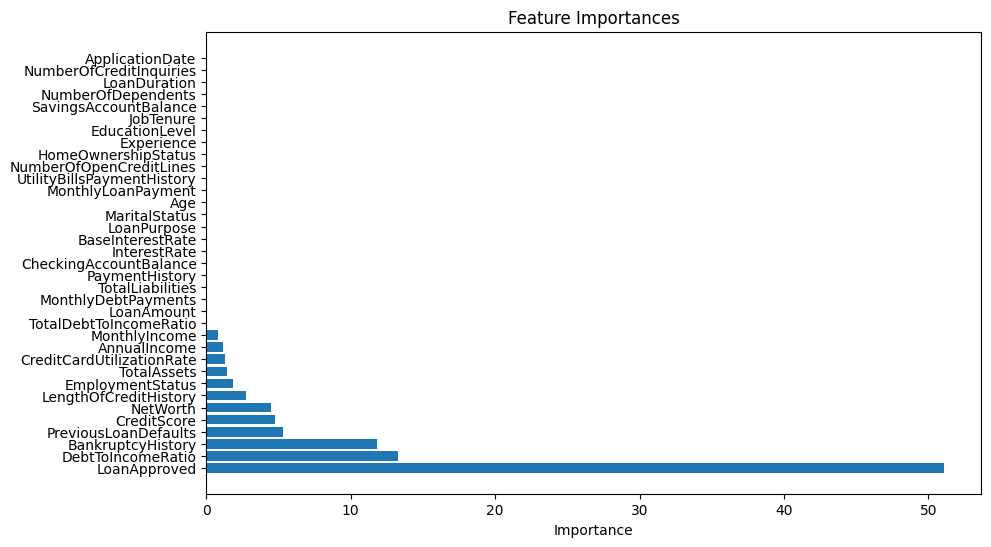

In [19]:
# feature importance
import matplotlib.pyplot as plt
feature_importances = model_baseline.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature Id'], feature_importances['Importances'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()


In [22]:
# -*- coding: utf-8 -*-
"""delta_hedging2025_to_implement.ipynb


# Delta Hedging Implementation Exercise
This exercise implements delta hedging to maintain a delta-neutral portfolio and simulate its performance.

(c) Gabriel Turinici 2025

### Key Variables and Their Significance
- **Stock Price (S):** Simulated paths of the stock price using Geometric Brownian Motion.
- **Delta (delta):** Represents the sensitivity of the option price to stock price changes.
- **Cash Balance (cash):** Tracks portfolio cash after hedging adjustments.
- **Transaction Costs (f):** Costs incurred while adjusting the hedge.

### Initial Position Setup
At the start of the simulation:
- The option is purchased at its initial price, \( option\_price\_0 \).
- The portfolio begins with a cash balance equal to \( option\_price\_0 - delta\_0 \times S_0 \), where \( delta\_0 \) is the initial delta, and \( S_0 \) is the initial stock price.
- The portfolio holds \( delta\_0 \) shares of the stock to hedge the option's exposure to changes in \( S_0 \).

### Explanation of the For Loop
The **for** loop iterates over the time steps of the simulation. Its purpose is to dynamically adjust the portfolio's holdings to maintain a delta-neutral position as the stock price changes. Here's what happens at each iteration:

1. **Risk-Free Growth of Cash:**
   The cash balance grows at the risk-free interest rate \( r \) over the time step \( dt \). This accounts for the fact that the uninvested cash in the portfolio earns interest.

2. **Recalculation of Delta:**
   The delta is recalculated at each time step based on the current stock price, remaining time to maturity, and option parameters. This updated delta reflects the new sensitivity of the option value to changes in the stock price.

3. **Adjusting for Delta Changes:**
   - The portfolio adjusts its holdings of the stock to match the new delta. If the delta increases, additional shares are purchased; if it decreases, shares are sold.
   - The cost of this adjustment is subtracted from the cash balance. Transaction costs, proportional to the number of shares bought or sold, are also deducted from the cash.

4. **Updating Delta:**
   After the adjustments, the new delta becomes the current delta for the next iteration.

### Final Adjustments at Maturity
At the end of the simulation (maturity):
1. **Option Payoff:**
   The option payoff is subtracted from the cash balance. For a call option, the payoff is \( \max(S_T - K, 0) \), where \( S_T \) is the stock price at maturity and \( K \) is the strike price.

2. **Liquidating Stock Holdings:**
   Any remaining shares in the portfolio are sold at the maturity stock price \( S_T \), and the proceeds are added to the cash balance.

### Summary of Implementation Steps
- **Initial Setup:** Compute the initial option price and delta, and initialize the cash balance.
- **Iterative Adjustments:** Use the for loop to update the cash balance, adjust the stock holdings, and account for transaction costs at each time step.
- **Final Adjustments:** Compute the option payoff and liquidate the remaining stock holdings to determine the final portfolio value.

This iterative process ensures that the portfolio remains delta-neutral throughout the option's lifetime, minimizing the risk associated with changes in the stock price.

#TODO
in all that follows replace "None" with correct implementation
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def blsprice(Price, Strike, Rate, TimeToMaturity, Volatility, DividendRate=0):
    if TimeToMaturity <= 1e-6:
        call = np.maximum(Price - Strike, 0)
        put = np.maximum(Strike - Price, 0)
        return call, put

    d1 = (np.log(Price / Strike) + (Rate - DividendRate + 0.5 * Volatility**2) * TimeToMaturity) / (Volatility * np.sqrt(TimeToMaturity))
    d2 = d1 - Volatility * np.sqrt(TimeToMaturity)
    call = Price * np.exp(-DividendRate * TimeToMaturity) * norm.cdf(d1) - Strike * np.exp(-Rate * TimeToMaturity) * norm.cdf(d2)
    put = Strike * np.exp(-Rate * TimeToMaturity) * norm.cdf(-d2) - Price * np.exp(-DividendRate * TimeToMaturity) * norm.cdf(-d1)
    return call, put

#test: blsprice(100,110,0.05,1,0.2)
#blsprice(np.array([100,101]),np.array([110,111]),0.05,1,0.2)

def blsdelta(Price,Strike,Rate,TimeToMaturity,Volatility,DividendRate=0):
    """input:
       S:Price - Current price of the underlying asset.

       Strike:Strike - Strike (i.e., exercise) price of the option.

       Rate: Rate - Annualized continuously compounded risk-free rate of return over
         the life of the option, expressed as a positive decimal number.

       TimeToMaturity:Time - Time to expiration of the option, expressed in years.

      Volatility: volatility
      DividendRate = continuous dividend rate
    """

    if TimeToMaturity <= 1e-6: # the option already expired
        call = (Price>=Strike).astype(float) # 1 if in the money, zero otherwise
        put = (Price<=Strike).astype(float) # cf above
        return call,put


    d1 = np.log(Price/Strike)+(Rate-DividendRate + Volatility**2/2.0)*TimeToMaturity;
    d1 = d1/(Volatility* np.sqrt(TimeToMaturity))

    call =  np.exp(-DividendRate*TimeToMaturity) * norm.cdf(d1)
    put  = -np.exp(-DividendRate*TimeToMaturity) * norm.cdf(-d1)
    return call,put

"""### Simulation Parameters
Set up parameters for stock price simulation and option valuation.
"""

T = 1  # Maturity time in years
N = 255  # Number of time steps
dt = T / N
M = 1000  # Number of simulations

S0 = 100
K = 110
mu = 0.15
sigma = 0.2
r = 0.05
f = 0.00



<>:18: SyntaxWarning: invalid escape sequence '\('
<>:18: SyntaxWarning: invalid escape sequence '\('
/var/folders/8z/k0b1vrlx00v464yzttq1x5k80000gn/T/ipykernel_5359/2056463602.py:18: SyntaxWarning: invalid escape sequence '\('
  - The option is purchased at its initial price, \( option\_price\_0 \).


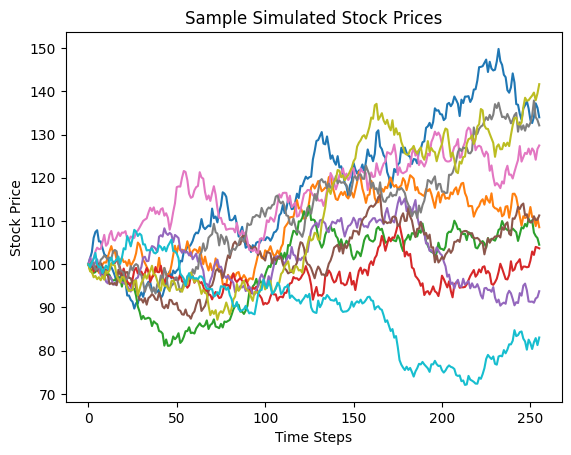

In [23]:

"""### Stock Price Simulation
Using Geometric Brownian Motion (GBM), simulate the stock price paths.
"""

dW = np.sqrt(dt) * np.random.randn(N, M)
W = np.zeros((N + 1, M))
W[1:, :] = np.cumsum(dW, axis=0)

t = np.linspace(0, T, N + 1)
S = S0 * np.exp((mu - 0.5 * sigma**2) * t[:, None] + sigma * W)

plt.plot(S[:, :10])
plt.title("Sample Simulated Stock Prices")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.show()


In [27]:

"""### Initial Portfolio Setup
Compute the initial option price, delta, and cash balance.
"""

cash = np.zeros_like(S)
delta=np.zeros((N+1,M))
initial_price=blsprice(S0,K,r,T,sigma)[0]
print(f"Initial option price: {initial_price}")
delta[0,:]  = blsdelta(S0,K,r,T,sigma)[0]  # Initial delta
cash[0, :]  = initial_price  # We add to the cash the initial price of the option
print(f"Initial cash: {cash}, {cash.shape}")
cash[0, :] -= delta[0,:]*S[0,:]  # substract from the cash the initial price of buying the hedging position


Initial option price: 6.040088129724239
Initial cash: [[6.04008813 6.04008813 6.04008813 ... 6.04008813 6.04008813 6.04008813]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]], (256, 1000)


In [28]:

"""### Delta Hedging Loop
Iteratively adjust the portfolio to remain delta-neutral.
"""
for jj in range(N):
    cash[jj + 1, :] = cash[jj, :] * np.exp(r * dt)  
    # Update cash with risk-free rate
    delta[jj+1,:] =   blsdelta(S[jj+1,:],K,r,T - (jj+1)*dt,sigma)[0]
    # Compute new delta based on current stock price
    cash[jj + 1, :] -= (delta[jj + 1, :] - delta[jj, :]) * S[jj + 1, :]
    # Adjust cash for delta change cost
    cash[jj + 1, :] -= f * np.abs(delta[jj + 1, :] - delta[jj, :]) * S[jj + 1, :]
    # Account for transaction costs


In [29]:

"""### Final Adjustments at Maturity
At the option's maturity, compute the payoff and liquidate remaining holdings.
"""

cash[-1, :] -= np.maximum(S[-1, :] - K, 0)
# Deduct option payoff
cash[-1, :] += delta[-1, :] * S[-1, :]
# Liquidate remaining shares


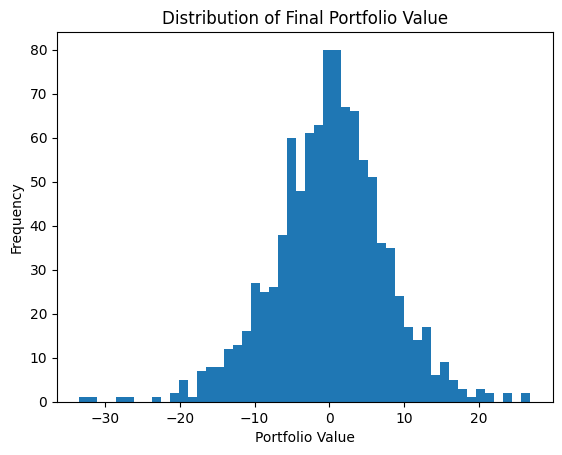

0.07949583704873396


In [31]:

"""### Final Portfolio Value Distribution
Plot the histogram of the final portfolio values.
"""

plt.hist(cash[-1, :]*100/initial_price, bins=50)
plt.title("Distribution of Final Portfolio Value")
plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")
plt.show()

"""#Monte Carlo pricing

Using a risk-neutral evolution compute the Monte Carlo price of the option
"""
print(sum(cash[-1, :]*100/initial_price)/M)